# Hospital Financial Distress Prediction
This notebook documents the process of building a model to predict financial status for acute care facilities using 5 years of CMS Medicare Cost Reports (2019-2023)

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, shap, warnings

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

## Data Loading 
Five years of CMS Medicare Cost Reports (2019-2023) are stacked into a single dataframe with a year column added for context.

In [105]:
df = pd.concat([
    pd.read_csv(f'data/CostReport_{year}_Final.csv').assign(year=year)
    for year in range(2019, 2024)
], ignore_index=True)

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (30400, 118)


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,year
0,650479,201302,LINCOLNHEALTH,6 ST. ANDREWS LANE,BOOTHBAY HARBOR,ME,04538-,LINCOLN,99920.0,R,...,61805.0,-517955.0,NaN,-517955.0,0.594265,1692896.0,2070344.0,NaN,NaN,2019
1,655727,342017,ASHEVILLE SPECIALTY HOSPITAL LLC,428 BILTMORE AVENUE,ASHEVILLE,NC,28801,BUNCOMBE,11700.0,U,...,54959.0,1033596.0,NaN,1033596.0,NaN,NaN,NaN,NaN,NaN,2019
2,661241,344033,WALTER B JONES LAKESIDE,2577 WEST FIFTH STREET,GREENVILLE,NC,27834,PITT,24780.0,U,...,7847.0,-918671.0,NaN,-918671.0,1.827490,NaN,NaN,NaN,NaN,2019
3,661372,341316,HIGHLANDS CASHIERS HOSPITAL,HIGHWAY 64E,HIGHLANDS,NC,28741-,MACON,99934.0,R,...,2785450.0,1482484.0,NaN,1482484.0,0.557117,162586.0,470364.0,NaN,NaN,2019
4,662990,670087,SCOTT & WHITE CEDAR PARK,900 E WHITESTONE BLVD,CEDAR PARK,TX,78613,WILLIAMSON,12420.0,U,...,91176.0,-486013.0,NaN,-486013.0,0.257723,67094.0,909270.0,NaN,NaN,2019


## Facility Type Filter
Non-acute care hospital types are removed from the data set as they have different patient populations and reimbursement models, and only comprise a fraction of the entire dataset. 

In [106]:
# Evaluate distribution of facility types
df['Provider Type'].value_counts()

Provider Type
1     23099
4      3082
2      1771
5      1745
7       407
9       152
3        62
6        54
12       18
10        6
11        4
Name: count, dtype: int64

In [ ]:
df = df[df['Provider Type'].isin([1, 3, 7, 12])]
df.shape

(23586, 118)

## Exploratory Data Analysis

In [108]:
# List of potential feature columns for model prediction. Features that are directly part of the target (Net Income) are eliminated as the goal is to determine if there are other non-financial factors that contribute to facility financial status

candidate_cols = [
    'Number of Beds', 'FTE - Employees on Payroll', 'Total Days Title V',
    'Total Days Title XVIII', 'Total Days Title XIX', 'Total Days (V + XVIII + XIX + Unknown)',
    'Total Bed Days Available', 'Total Discharges Title V', 'Total Discharges Title XVIII',
    'Total Discharges Title XIX', 'Total Discharges (V + XVIII + XIX + Unknown)', 
    'Cost of Charity Care', 'Cost of Uncompensated Care', 'Inpatient Total Charges',
    'Outpatient Total Charges', 'Combined Outpatient + Inpatient Total Charges',
    'Rural Versus Urban', 'Provider Type', 'Type of Control', 'CCN Facility Type', 'State Code', 'Net Income'
]

df[candidate_cols].describe().round(2)

,Number of Beds,FTE - Employees on Payroll,Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Cost of Charity Care,Cost of Uncompensated Care,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Provider Type,Type of Control,Net Income
count,23351.00,23291.00,667.00,23161.00,21188.00,23309.00,23351.00,623.00,23195.00,20814.00,23304.00,2.129200e+04,2.246700e+04,2.336400e+04,2.336100e+04,2.340300e+04,23586.00,23586.00,2.338000e+04
mean,226.42,1040.06,2313.04,8798.19,3619.83,33996.60,53444.07,439.95,1633.93,629.10,6588.12,6.614668e+06,9.011397e+06,4.958250e+08,4.964171e+08,9.905249e+08,1.12,4.02,1.786298e+07
std,10487.35,1864.89,5301.49,13720.24,8173.41,55226.47,70790.20,694.46,2358.21,1358.61,9833.23,2.020080e+07,2.367870e+07,1.058986e+09,9.044303e+08,1.901446e+09,0.84,3.38,1.117910e+08
min,1.00,0.01,1.00,1.00,1.00,1.00,26.00,1.00,1.00,1.00,1.00,1.000000e+00,-1.569430e+05,1.000000e+00,7.000000e+01,1.000000e+00,1.00,1.00,-3.955820e+09
25%,25.00,154.52,99.50,1007.00,114.00,2638.00,9125.00,14.00,158.00,26.00,455.00,3.468900e+05,1.037286e+06,1.308695e+07,4.988978e+07,6.723059e+07,1.00,2.00,-1.204512e+06
50%,70.00,414.56,607.00,2812.00,751.00,10085.00,24820.00,150.00,594.00,147.00,2418.00,1.632076e+06,2.963322e+06,9.348238e+07,1.943806e+08,2.951533e+08,1.00,2.00,3.105010e+06
75%,201.00,1160.29,2520.50,11364.00,3356.00,44625.00,72635.00,585.50,2268.00,609.75,9335.50,5.748094e+06,8.460310e+06,5.306452e+08,6.092785e+08,1.156548e+09,1.00,4.00,1.779454e+07
max,1594784.00,33793.00,67185.00,208248.00,139073.00,911866.00,1040250.00,7148.00,31284.00,19799.00,168398.00,8.192046e+08,8.504827e+08,2.447432e+10,2.337112e+10,4.511504e+10,12.00,13.00,7.919570e+09


In [109]:
# At the time of this project published public information states New York Presbyterian Weill Cornell Medical Center is the largest hospital by bed count with 2,850 beds
df[df['Number of Beds'] > 3000][['Hospital Name', 'City', 'year', 'Provider Type', 'FTE - Employees on Payroll', 'Number of Beds', 'Total Bed Days Available']].sort_values(by='Hospital Name')

,Hospital Name,City,year,Provider Type,FTE - Employees on Payroll,Number of Beds,Total Bed Days Available
728,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,2019,1,134.62,52913.0,7665.0
7582,MERCY HOSPITAL & MEDICAL CENTER,CHICAGO,2020,1,958.07,144837.0,61437.0
4404,OKLAHOMA HEART HOSPITAL,OKLAHOMA CITY,2019,1,1564.52,28401.0,36135.0
10337,WAYNE HOSPITAL COMPANY,GREENVILLE,2020,1,371.00,1594784.0,14640.0


In [110]:
# Checking for data on the hospitals with unusually high bed counts in other years to verify outlier status
bed_outlier_ccns = df[df['Number of Beds'] > 3000]['Provider CCN'].tolist()
df[df['Provider CCN'].isin(bed_outlier_ccns)][['Hospital Name', 'year', 'Number of Beds', 'Total Bed Days Available']].sort_values(by=['Hospital Name', 'year'])

,Hospital Name,year,Number of Beds,Total Bed Days Available
728,BEAR LAKE MEMORIAL HOSPITAL,2019,52913.0,7665.0
6274,BEAR LAKE MEMORIAL HOSPITAL,2020,21.0,7686.0
12408,BEAR LAKE MEMORIAL HOSPITAL,2021,21.0,7665.0
18895,BEAR LAKE MEMORIAL HOSPITAL,2022,21.0,7665.0
25311,BEAR LAKE MEMORIAL HOSPITAL,2023,21.0,7665.0
15974,INSIGHTS HOSPITAL AND MEDICAL CENTER,2021,52.0,11180.0
20040,INSIGHTS HOSPITAL AND MEDICAL CENTER,2022,52.0,18980.0
26552,INSIGHTS HOSPITAL AND MEDICAL CENTER,2023,52.0,18980.0
2895,MERCY HOSPITAL & MEDICAL CENTER,2019,203.0,74095.0
7582,MERCY HOSPITAL & MEDICAL CENTER,2020,144837.0,61437.0


In [111]:
# Removing rows with confirmed single year reporting errors. 
df = df[df['Number of Beds'] <= 3000]
df.shape

(23347, 118)

In [113]:
df[['FTE - Employees on Payroll', 'Number of Beds']].corr()

,FTE - Employees on Payroll,Number of Beds
FTE - Employees on Payroll,1.000000,0.843777
Number of Beds,0.843777,1.000000


In [114]:
df[candidate_cols].isnull().sum().sort_values(ascending=False)

Total Discharges Title V                         22724
Total Days Title V                               22680
Total Discharges Title XIX                        2538
Total Days Title XIX                              2165
Cost of Charity Care                              2077
Cost of Uncompensated Care                         914
Total Days Title XVIII                             192
Total Discharges Title XVIII                       158
FTE - Employees on Payroll                          93
Total Discharges (V + XVIII + XIX + Unknown)        49
Total Days (V + XVIII + XIX + Unknown)              45
Outpatient Total Charges                            41
Net Income                                          27
Inpatient Total Charges                             10
Total Bed Days Available                             2
Combined Outpatient + Inpatient Total Charges        1
Number of Beds                                       0
Rural Versus Urban                                   0
Provider T

In [116]:
print(f'Total Days Title XIX')
df.groupby('CCN Facility Type')['Total Days Title XIX'].agg(
    null_count = lambda x: x.isna().sum(),
    null_pct = lambda x: x.isna().mean().round(4) * 100
)

Total Days Title XIX


,null_count,null_pct
CCN Facility Type,,
CAH,1132,16.76
CH,7,2.19
ORD,27,65.85
STH,999,6.15


In [117]:
print('Cost of Charity Care')
df.groupby('CCN Facility Type')['Cost of Charity Care'].agg(
    null_count = lambda x: x.isna().sum(),
    null_pct = lambda x: x.isna().mean().round(4) * 100
)

Cost of Charity Care


,null_count,null_pct
CCN Facility Type,,
CAH,476,7.05
CH,297,92.81
ORD,1,2.44
STH,1303,8.03


In [118]:
print(f'Cost of Uncompensated Care')
df.groupby('CCN Facility Type')['Cost of Uncompensated Care'].agg(
    null_count = lambda x: x.isna().sum(),
    null_pct = lambda x: x.isna().mean().round(4) * 100
)

Cost of Uncompensated Care


,null_count,null_pct
CCN Facility Type,,
CAH,94,1.39
CH,287,89.69
ORD,0,0.00
STH,533,3.28


In [119]:
df['CCN Facility Type'].value_counts()

CCN Facility Type
STH    16233
CAH     6753
CH       320
ORD       41
Name: count, dtype: int64

In [120]:
# Children's Hospitals (CH) and Hospitals Participating in an ORD demonstration project (ORD) are removed based on high rates of null values in feature columns and low overall incidence in the data
df = df[~df['CCN Facility Type'].isin(['CH', 'ORD'])]

# Drop the 27 rows where the target is null
df = df.dropna(subset=['Net Income'])
print(f'Shape: {df.shape}')

# Null recheck
df[candidate_cols].isnull().sum().sort_values(ascending=False)

Shape: (22959, 118)


Total Discharges Title V                         22383
Total Days Title V                               22340
Total Discharges Title XIX                        2503
Total Days Title XIX                              2130
Cost of Charity Care                              1779
Cost of Uncompensated Care                         627
Total Days Title XVIII                             145
Total Discharges Title XVIII                       114
FTE - Employees on Payroll                          91
Total Discharges (V + XVIII + XIX + Unknown)        49
Total Days (V + XVIII + XIX + Unknown)              45
Outpatient Total Charges                            41
Inpatient Total Charges                             10
Total Bed Days Available                             2
Combined Outpatient + Inpatient Total Charges        1
Number of Beds                                       0
Rural Versus Urban                                   0
Provider Type                                        0
Type of Co

In [149]:
low_null_cols = [
    "Total Days (V + XVIII + XIX + Unknown)",
    'Total Discharges (V + XVIII + XIX + Unknown)',
    "Total Days Title XVIII",
    'Total Discharges Title XVIII',
    "Total Bed Days Available",
    "Combined Outpatient + Inpatient Total Charges",
    "Outpatient Total Charges",
    "Inpatient Total Charges"
]

moderate_null_cols = [
    "Total Days Title XIX",
    "Cost of Charity Care",
    "Cost of Uncompensated Care"
]

In [124]:
all_null_cols = low_null_cols + moderate_null_cols
print(f"Rows with any null across all candidate columns: {df[all_null_cols].isnull().any(axis=1).sum()}")
print(f"Rows with nulls in low_null_cols only: {df[low_null_cols].isnull().any(axis=1).sum()}")
print(f"Rows with nulls in moderate_null_cols only: {df[moderate_null_cols].isnull().any(axis=1).sum()}")
print(f"Rows with nulls in both groups: {(df[low_null_cols].isnull().any(axis=1) & df[moderate_null_cols].isnull().any(axis=1)).sum()}")

Rows with any null across all candidate columns: 3552
Rows with nulls in low_null_cols only: 191
Rows with nulls in moderate_null_cols only: 3493
Rows with nulls in both groups: 132


In [126]:
df = df.dropna(subset=low_null_cols)
df.shape

(22768, 118)

## Feature Engineering
Reported variables are created for medicaid, uncompensated care, and charity care to give the model the opportunity to identify differences between those that report the metric and those that do not. Operational features are expressed as ratios rather than raw counts to control for hospital size. 

In [151]:
source_cols = [
    'Provider CCN', 'Hospital Name', 'City', 'State Code', 'Rural Versus Urban',
    'Provider Type', 'Type of Control', 'CCN Facility Type', 'Number of Beds',
    'Total Days Title V', 'Total Days Title XVIII', 'Total Days Title XIX', 
    'Total Days (V + XVIII + XIX + Unknown)', 'Total Bed Days Available', 
    'Total Discharges Title V', 'Total Discharges Title XVIII', 'Total Discharges Title XIX', 
    'Total Discharges (V + XVIII + XIX + Unknown)', 'Cost of Charity Care',
    'Cost of Uncompensated Care', 'Combined Outpatient + Inpatient Total Charges',
    'Net Income'
]
data = df[source_cols].copy()
print(f'df shape: {df.shape}')
print(f'data shape: {data.shape}')

df shape: (22768, 128)
data shape: (22768, 22)


In [171]:
data['medicare_pct'] = data['Total Discharges Title XVIII'] / data['Total Discharges (V + XVIII + XIX + Unknown)']
data['medicaid_pct'] = data['Total Discharges Title XIX'] / data['Total Discharges (V + XVIII + XIX + Unknown)']
data['bed_utilization'] = data['Total Days (V + XVIII + XIX + Unknown)'] / data['Total Bed Days Available']
data['avg_length_of_stay'] = data['Total Days (V + XVIII + XIX + Unknown)'] / data['Total Discharges (V + XVIII + XIX + Unknown)']
data['uncompensated_care_pct'] = data['Cost of Uncompensated Care'] / data['Combined Outpatient + Inpatient Total Charges']
data['charity_care_pct'] = data['Cost of Charity Care'] / data['Combined Outpatient + Inpatient Total Charges']
data['medicaid_reported'] = data['Total Discharges Title XIX'].notnull().astype(int)
data['uncompensated_reported'] = data['Cost of Uncompensated Care'].notnull().astype(int)
data['charity_reported'] = data['Cost of Charity Care'].notnull().astype(int)
data['financial_distress'] = (data['Net Income'] < 0).astype(int)

In [ ]:
conditions = [
    data['Type of Control'].between(1, 2),
    data['Type of Control'].between(3, 6),
    data['Type of Control'].between(7, 13)
]

choices = [
    'Non-Profit', 'For-Profit', 'Government'
]

data['control_type'] = np.select(conditions, choices, 'ERROR')
data['control_type'].value_counts()


control_type
Non-Profit    13640
Government     5008
For-Profit     4120
Name: count, dtype: int64

In [ ]:
numeric_features = [
    'medicare_pct', 'medicaid_pct', 'bed_utilization',
    'avg_length_of_stay', 'uncompensated_care_pct', 'charity_care_pct',
    'medicaid_reported', 'uncompensated_reported', 'charity_reported'
]

categorical_features = [
    'Rural Versus Urban', 'CCN Facility Type', 'control_type'
]

target = ['financial_distress']

In [170]:
# Replace null values in engineered numeric features with 0 to prevent model errors
data[['medicaid_pct', 'uncompensated_care_pct', 'charity_care_pct']] = data[["medicaid_pct", "uncompensated_care_pct", "charity_care_pct"]].fillna(0)

# Final data review before visualization
print(f'Data Shape: {data.shape}')
print('Null Counts')
print(data[numeric_features + categorical_features + target].isnull().sum())
print()
print('Inf counts:')
print((data[numeric_features] == np.inf).sum())
print()
print('Negative inf counts:')
print((data[numeric_features] == -np.inf).sum())

Data Shape: (22768, 33)
Null Counts
medicare_pct              0
medicaid_pct              0
bed_utilization           0
avg_length_of_stay        0
uncompensated_care_pct    0
charity_care_pct          0
uncompensated_reported    0
charity_reported          0
Rural Versus Urban        0
CCN Facility Type         0
control_type              0
financial_distress        0
dtype: int64

Inf counts:
medicare_pct              0
medicaid_pct              0
bed_utilization           0
avg_length_of_stay        0
uncompensated_care_pct    0
charity_care_pct          0
uncompensated_reported    0
charity_reported          0
dtype: int64

Negative inf counts:
medicare_pct              0
medicaid_pct              0
bed_utilization           0
avg_length_of_stay        0
uncompensated_care_pct    0
charity_care_pct          0
uncompensated_reported    0
charity_reported          0
dtype: int64


# Exploratory Data Analysis

In [189]:
data.info()

<class 'pandas.DataFrame'>
Index: 22768 entries, 0 to 30399
Data columns (total 34 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Provider CCN                                   22768 non-null  int64  
 1   Hospital Name                                  22768 non-null  str    
 2   City                                           22768 non-null  str    
 3   State Code                                     22768 non-null  str    
 4   Rural Versus Urban                             22768 non-null  str    
 5   Provider Type                                  22768 non-null  int64  
 6   Type of Control                                22768 non-null  int64  
 7   CCN Facility Type                              22768 non-null  str    
 8   Number of Beds                                 22768 non-null  float64
 9   Total Days Title V                             618 non-null    flo

In [191]:
data[numeric_features + categorical_features].describe()

,medicare_pct,medicaid_pct,bed_utilization,avg_length_of_stay,uncompensated_care_pct,charity_care_pct,uncompensated_reported,charity_reported
count,22768.000000,20384.000000,22768.000000,22768.000000,22187.000000,2.107600e+04,22768.000000,22768.000000
mean,0.342887,0.090007,0.466163,11.373372,0.019528,1.036062e-02,0.974482,0.925685
std,0.168626,0.105478,0.239683,125.645735,0.052267,4.311220e-02,0.157696,0.262288
min,0.000985,0.000050,0.000015,0.013220,-0.000618,6.411729e-09,0.000000,0.000000
25%,0.227134,0.021812,0.267650,3.935544,0.005485,2.122423e-03,1.000000,1.000000
50%,0.312500,0.048387,0.463041,4.733352,0.010308,4.550512e-03,1.000000,1.000000
75%,0.427124,0.119601,0.655699,5.837677,0.019893,9.482703e-03,1.000000,1.000000
max,1.000000,0.875000,3.620822,8067.000000,3.384972,3.378542e+00,1.000000,1.000000


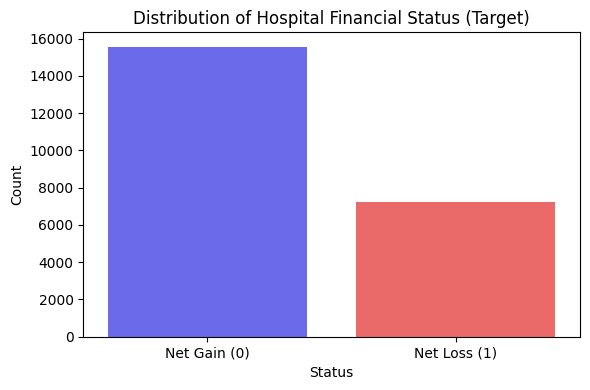

In [188]:
mapping = {0: 'Net Gain (0)', 1: 'Net Loss (1)'}
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=data, x='financial_distress', hue='financial_distress', palette='seismic', formatter=mapping, legend=False)
ax.set(title='Distribution of Hospital Financial Status (Target)', xlabel='Status', ylabel='Count')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i+1)
    sns.hisplot(
        data=data,
        x=col,
        hue='financial_distress',
    )